In [5]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [6]:
compute_case_monophasic = True
if compute_case_monophasic:
    case_name = "genfoam_comparaison_correl"
    #User choice:
    solveConduction = False
    plot_at_z1 = [0.8]

    ########## Thermal hydraulics parameters ##########
    ## Geometric parameters
    canalType = "square"
    waterRadius = 0.0133409 # m
    fuelRadius = 0.00542310/2 # m : fuel rod radius
    gapRadius = fuelRadius + 0.0000000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
    cladRadius =  0.0094996/2 # m : clad external radius
    height = 1.655 # m : height : active core height in BWRX-300 SMR

    ## Fluid parameters
    pOutlet = 14719781.65 # Pa
    tInlet = 592.75 #K
    u_inlet = 4.467092221 #m/s
    pressureDrop = 186737 #Pa/m
    falsePInlet = pOutlet - height * pressureDrop
    rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
    flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
    qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s

    ## Meshing parameters:
    If = 8
    I1 = 3
    Iz1 = 75 # number of control volumes in the axial direction

    ## Thermalhydraulics correlation
    voidFractionCorrel = "EPRIvoidModel"
    frfaccorel = "blasius"
    P2Pcorel = "lockhartMartinelli"
    numericalMethod = 'FVM'

    ############ Nuclear Parameters ###########
    ## Fission parameters
    qFiss = 1943301220 # W/m3

    ## Material parameters
    kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
    Hgap = 10000
    kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
    # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
    ########## Algorithm parameters ###########
    nIter = 1000
    tol = 1e-4


    Iz1 = 75
    Qfiss1 = []
    for i in range(Iz1): 
        if i*(height/Iz1) < 0.1:
            Qfiss1.append(0)
        else:
            Qfiss1.append(qFiss)
    print(Qfiss1)
    case0 = Version5_THM_prototype(case_name, canalType,
                 waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                 kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                 dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
    

[0, 0, 0, 0, 0, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220]
$$$---------- THM: prototype, case treated : genfoam_comparaison_correl.
$$$---------- THM: prototype, steady state case.
$$---------- Calling D

In [13]:
class GFPlotter():
    def __init__(self, caseList, directory_path):
        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            print(data_lines)
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid']+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour']+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = self.alpha_liquid * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        print(f"rho_liquid: {self.rho_liquid}")
        print(f"rho_vapour: {self.rho_vapour}")
        self.rho_mixture = self.alpha_liquid * self.rho_liquid + self.alpha_vapour * self.rho_vapour

        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)

    def plotComparison(self):
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam")
        ax1.step(self.zList, self.T_vapour, label="GenFoam")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")

        fig3, ax3 = plt.subplots()
        print(f"rho_mix: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho_liquid, label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho_vapour, label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")

        plt.show()


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BW

C:\Users\cleme\AppData\Local\Temp\ipykernel_12936\1084790360.py:104: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


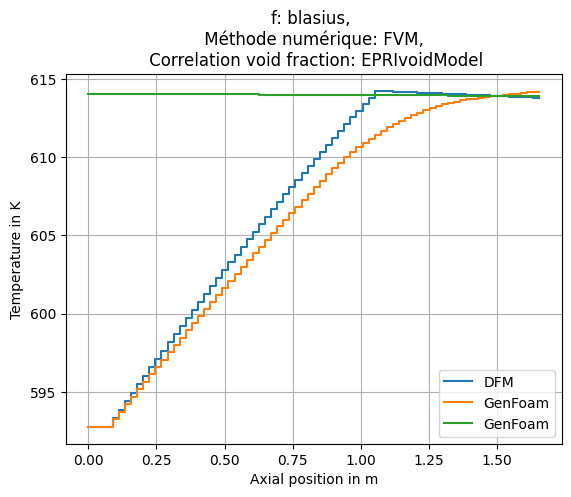

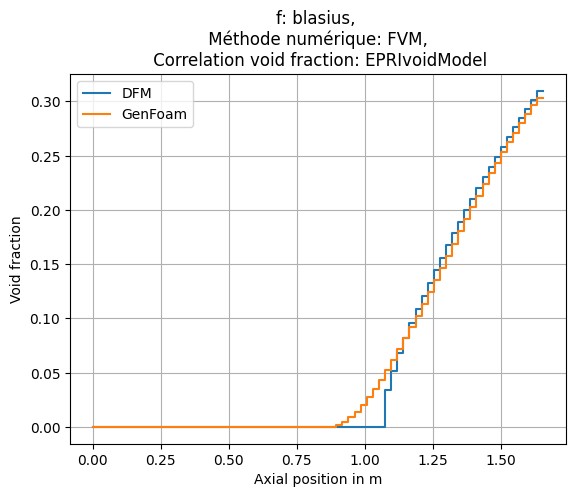

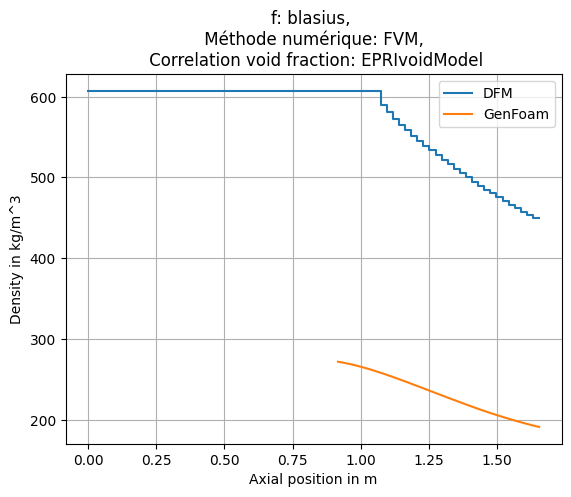

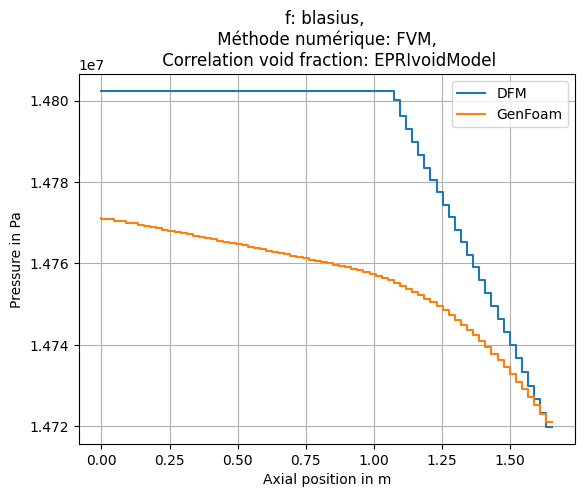

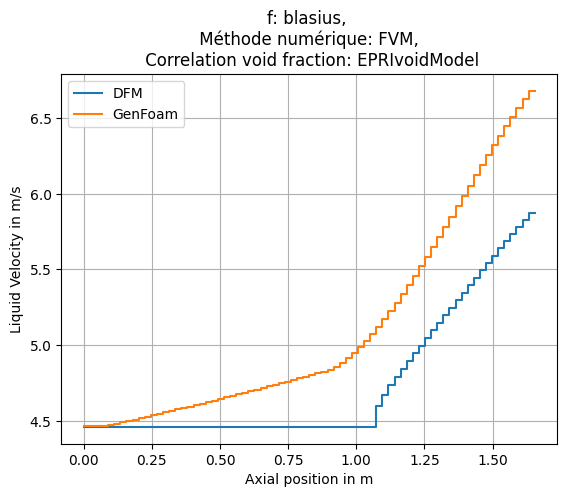

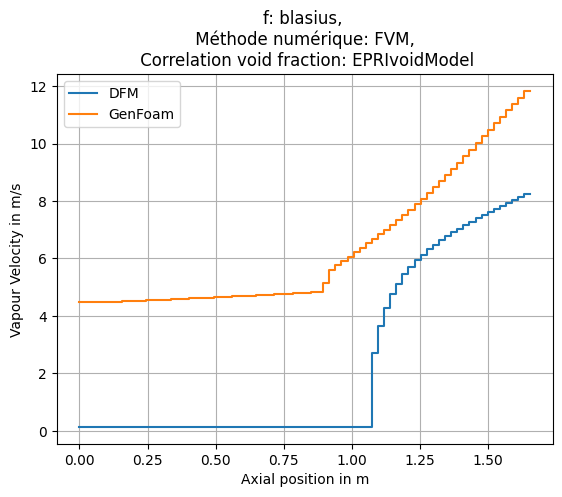

Umixture: [1.94091921 1.9409279  1.94093659 1.94094528 1.94095397 1.94291353
 1.94684134 1.95079956 1.95478385 1.95879856 1.96284368 1.96691487
 1.97101213 1.9751398  1.97929355 1.9834777  1.98768359 1.99191988
 1.99618225 2.00046634 2.00478085 2.00911708 2.01347938 2.0178634
 2.02227784 2.02670966 2.03116755 2.03564716 2.04015284 2.0446759
 2.04922503 2.05379154 2.05838413 2.06299409 2.06762143 2.07227049
 2.07694128 2.08162945 2.086335   2.09106227 2.09580258 2.10219438
 2.11218795 2.12523736 2.14113466 2.15984807 2.1812295  2.20516976
 2.23159376 2.2604307  2.29163734 2.32517193 2.36099816 2.39907613
 2.43937276 2.48183421 2.52643301 2.57310414 2.62179912 2.67245242
 2.72500213 2.7797355  2.83667975 2.8953555  2.95531659 3.01633526
 3.07825078 3.14070853 3.20338263 3.26620019 3.32916021 3.39223643
 3.45544813 3.51881843 3.58182077]


In [14]:
plotter = GFPlotter([case0], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_base')
plotter.plotComparison()
print(f'Umixture: {plotter.U_mixture}')